# Learn the harmonic (2,1) forms

In [ ]:
import os
import pickle

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as tfk
from tqdm import tqdm

import importlib
import warped_metrics
importlib.reload(warped_metrics)

from warped_metrics import (
    BoostedSpectralPhiModel,
    BoostedSpectralPhiModel_ambient,
    PointGeneratorMathematica,
    PointGeneratorMathematicaIPS,
    SigmaCallback,
    VolkCallback,
    SigmaLoss,
    build_phi_network,
    configure_tensorflow_runtime,
    prepare_tf_basis,
    pullbacks,
    train_model,
    levi_civita_tensor,
    calc_derivatives_fast,
    holomorphic_volume_form,
    calculate_dQdz,
    calculate_ddQdz,
    make_dataset_cached_pb,
    build_harm_nn,
    HarmonicFormModelCachedPB,
    calc_d_theta_par,
    WarpFactorModel
)

configure_tensorflow_runtime(cpu_only=True)

## Learn two-step metric 

In [ ]:
psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
nhyper = 1
num_pts = 100000
num_regions = 5
chis = []
n_try = 6

pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)
base_dir = "IPS"
dirname = os.path.join(base_dir,"points_quintic_{:}_{:}_{:}".format(psi, num_pts, n_try))
if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
    kappas = pg.prepare_dataset(num_pts, dirname)
    pg.prepare_basis(dirname, kappas)

data = np.load(os.path.join(dirname, 'dataset.npz'))
BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
BASIS = prepare_tf_basis(BASIS)
new_basis = {}
for key in BASIS:
    new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
BASIS = new_basis

absl:WARNING:At this time, the v2.11+ optimizer `tf.keras.optimizers.Adam` runs slowly on M1/M2 Macs, please use the legacy Keras optimizer instead, located at `tf.keras.optimizers.legacy.Adam`.


<Axes: xlabel='epochs', ylabel='sigma_val'>

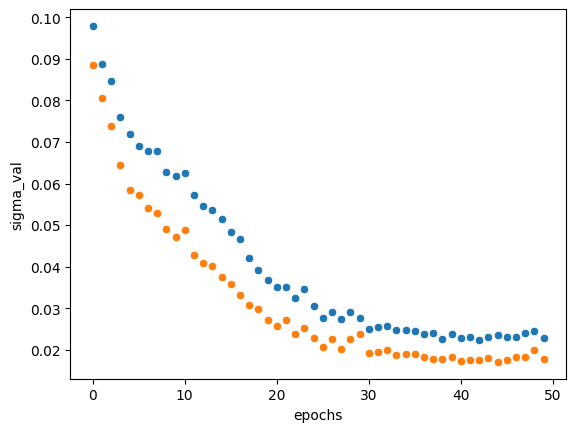

In [ ]:
psi = 1.035 - 0.02 * 1.j
monomials = np.array((5 * np.eye(5, dtype=np.int64)).tolist() + [[1,1,1,1,1]])
coefficients = np.array(np.ones(5).tolist() + [-5 * psi])
kmoduli = np.ones(1)
ambient = np.array([4])
n_fold = 3
nhyper = 1
num_pts = 100000
num_regions = 5
chis = []
n_try = 6

pg = PointGeneratorMathematica([monomials], [coefficients], kmoduli, ambient)
base_dir = "IPS"
dirname = os.path.join(base_dir,"points_quintic_{:}_{:}_{:}".format(psi, num_pts, n_try))
if not os.path.exists(os.path.join(dirname, 'basis.pickle')):
    kappas = pg.prepare_dataset(num_pts, dirname)
    pg.prepare_basis(dirname, kappas)

data = np.load(os.path.join(dirname, 'dataset.npz'))
BASIS = np.load(os.path.join(dirname, 'basis.pickle'), allow_pickle=True)
BASIS = prepare_tf_basis(BASIS)
new_basis = {}
for key in BASIS:
    new_basis[key] = tf.cast(BASIS[key], dtype=tf.complex64)
BASIS = new_basis

# train first NN 
deg = 2
nlayers = 2
nHidden = 64
n_in = 2 * (BoostedSpectralPhiModel.get_num_sections(n_fold + 2, deg))**2
n_out = 1
act = "gelu"
nEpochs = 50
bSizes = [64, 20000]
alpha = [1., 1., 1., 1., 1.]

# ---- cheaper callback validation subset ----
Xv, yv = data["X_val"], data["y_val"]
val_cb_n = min(len(Xv), 5000)
cb_data = (Xv[:val_cb_n], yv[:val_cb_n])

scb = SigmaCallback(cb_data)
volkcb = VolkCallback(cb_data)
cb_list = [scb, volkcb]

test_metrics = [SigmaLoss()]

# ---- build model ----
nn_phi_1 = tf.keras.Sequential()
nn_phi_1.add(tfk.Input(shape=(n_in,)))
for _ in range(nlayers):
    nn_phi_1.add(tfk.layers.Dense(nHidden, activation=act))
# dtype float32 to be safe with mixed precision
nn_phi_1.add(tfk.layers.Dense(n_out, use_bias=False, dtype="float32"))

model_path = os.path.join(dirname, "nn_phi_1.keras")
hist_path  = os.path.join(dirname, "training_history_1.pickle")

phimodel = BoostedSpectralPhiModel([nn_phi_1], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

# optimizer (simple + fast)
opt_phi = tfk.optimizers.Adam(learning_rate=1e-3)

if not os.path.exists(model_path):
    # optional: reduce verbosity for speed
    phimodel, training_history = train_model(
        phimodel,
        data,
        optimizer=opt_phi,
        epochs=nEpochs,
        batch_sizes=bSizes,
        verbose=1,
        custom_metrics=test_metrics,
        callbacks=cb_list,
    )
    nn_phi_1 = phimodel.models[-1]
    nn_phi_1.save(model_path)
    with open(hist_path, "wb") as f:
        pickle.dump(training_history, f)

nn_phi_1 = tf.keras.models.load_model(model_path, compile=False)
nn_phi_1.trainable = True
_ = nn_phi_1(tf.zeros((1, n_in), dtype=tf.float32))

with open(hist_path, "rb") as f:
    training_history_1 = pickle.load(f)

    
sns.scatterplot(training_history_1, x='epochs', y='sigma_val')
sns.scatterplot(training_history_1, x='epochs', y='sigma_loss')

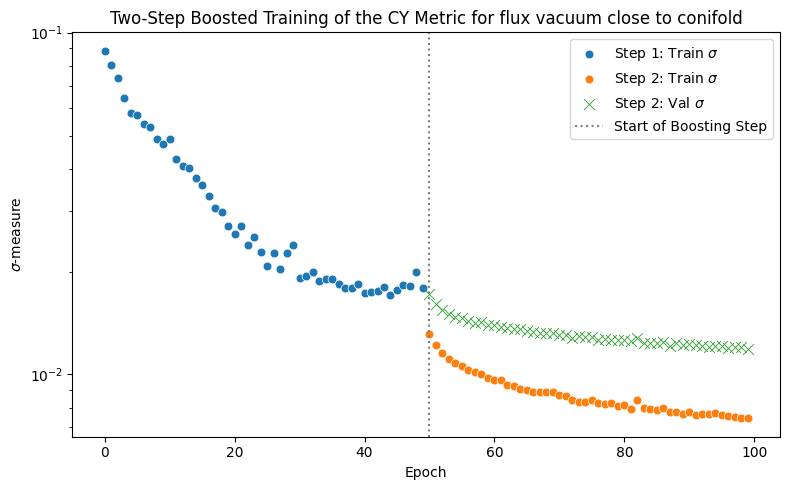

In [ ]:
#now train next NN with starting point given by the trained first NN 

# need smaller batch sizes with two NN to not crash the kernel.
bSizes = [64, 20000]

phi2_path  = os.path.join(dirname, "nn_phi_2.keras")
hist2_path = os.path.join(dirname, "training_history_2.pickle")

if os.path.exists(phi2_path):
    nn_phi_2 = tf.keras.models.load_model(phi2_path, compile=False)
else:
    nn_phi_2 = build_phi_network(n_in, nlayers, nHidden, act, n_out=n_out, mixed_precision_safe=True)

    _ = nn_phi_1(tf.zeros((1, n_in), dtype=tf.float32))
    _ = nn_phi_2(tf.zeros((1, n_in), dtype=tf.float32))
    nn_phi_2.set_weights(nn_phi_1.get_weights())

    phimodel_2_tmp = BoostedSpectralPhiModel([nn_phi_1, nn_phi_2], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

    opt_phi = tfk.optimizers.Adam(learning_rate=1e-3)
    phimodel_2_tmp, training_history_2 = train_model(
        phimodel_2_tmp, data,
        optimizer=opt_phi,
        epochs=nEpochs,
        batch_sizes=bSizes,
        verbose=1,
        custom_metrics=test_metrics,
        callbacks=cb_list,
    )

    nn_phi_2 = phimodel_2_tmp.models[-1]
    nn_phi_2.save(phi2_path)
    with open(hist2_path, "wb") as f:
        pickle.dump(training_history_2, f)

# ensure built
nn_phi_2.trainable = True
_ = nn_phi_2(tf.zeros((1, n_in), dtype=tf.float32))

# always create phimodel_2 (whether loaded or trained)
phimodel_2 = BoostedSpectralPhiModel([nn_phi_1, nn_phi_2], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

# history
training_history_2 = None
if os.path.exists(hist2_path):
    with open(hist2_path, "rb") as f:
        training_history_2 = pickle.load(f)

sigma_loss_1 = np.array(training_history_1['sigma_loss'])
sigma_loss_2 = np.array(training_history_2['sigma_loss'])
sigma_val_2  = np.array(training_history_2['sigma_val'])

# Epoch indexing
epochs_1 = np.arange(len(sigma_loss_1))
epochs_2 = np.arange(len(sigma_loss_1),
                     len(sigma_loss_1) + len(sigma_loss_2))

plt.figure(figsize=(8,5))

# Step 1 training
sns.scatterplot(
    x=epochs_1,
    y=sigma_loss_1,
    label="Step 1: Train $\sigma$",
    s=40
)

# Step 2 training
sns.scatterplot(
    x=epochs_2,
    y=sigma_loss_2,
    label="Step 2: Train $\sigma$",
    s=40
)

# Step 2 validation
sns.scatterplot(
    x=epochs_2,
    y=sigma_val_2,
    marker="x",
    label="Step 2: Val $\sigma$",
    s=60
)

# Vertical transition line (now in legend)
plt.axvline(
    len(sigma_loss_1),
    color='gray',
    linestyle=':',
    linewidth=1.5,
    label="Start of Boosting Step"
)
#plt.ylim(5e-3, 1e-1)  
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel(r"$\sigma$-measure")
plt.title("Two-Step Boosted Training of the CY Metric for flux vacuum close to conifold")

plt.legend()
plt.tight_layout()

plt.savefig(f"cy_metric_two_step_training_close_dataset_6.pdf",
            bbox_inches="tight",
            dpi=300)

plt.show()


## Load IPS data to learn harmonic forms for them

In [ ]:
pg = PointGeneratorMathematicaIPS([monomials], [coefficients], kmoduli, ambient, kernel_path='/Applications/Wolfram.app/Contents/MacOS/MathKernel')

n_try = 6
dirname_ips = os.path.join(base_dir,"points_quintic_ips_{:}_{:}_{:}".format(psi, num_pts, n_try))
if not os.path.exists(os.path.join(dirname_ips, 'basis.pickle')):
    kappas = pg.prepare_dataset(num_pts, dirname_ips, psi=psi)
    pg.prepare_basis(dirname_ips, kappas)

data_ips = np.load(os.path.join(dirname_ips, 'dataset.npz'))
BASIS_ips = np.load(os.path.join(dirname_ips, 'basis.pickle'), allow_pickle=True)
BASIS_ips = prepare_tf_basis(BASIS_ips)
new_basis_ips = {}
for key in BASIS_ips:
    new_basis_ips[key] = tf.cast(BASIS_ips[key], dtype=tf.complex64)
BASIS_ips = new_basis_ips

# --- try-invariant precomputation ---
ncoords = n_fold + 2
qI = tf.ones(5, dtype=tf.complex64)

# dQ/dz
obj = calculate_dQdz(ncoords, monomials, coefficients)
dQdz_total = obj._generate_dQdz_basis()
shape = np.array([np.shape(mb) for mb in dQdz_total[0]])
DQDZB = np.zeros((len(shape), np.max(shape[:, 0]), len(shape)), dtype=np.complex64)
DQDZF = np.zeros((len(shape), np.max(shape[:, 0])), dtype=np.complex64)
for i, m in enumerate(zip(dQdz_total[0], dQdz_total[1])):
    DQDZB[i, 0:shape[i, 0]] += m[0]
    DQDZF[i, 0:shape[i, 0]] += m[1]
DQDZB = tf.cast(DQDZB, tf.complex64)
DQDZF = tf.cast(DQDZF, tf.complex64)

# d^2Q/dz^A dz^B
obj = calculate_ddQdz(ncoords, monomials, coefficients)
ddQdz_total = obj.calculate_basis()
shape = np.array([np.shape(mb) for mb in ddQdz_total[0]])
DDQDZB = np.zeros((ncoords, ncoords, np.max(shape[:, 0]), ncoords), dtype=np.complex64)
DDQDZF = np.zeros((ncoords, ncoords, np.max(shape[:, 0])), dtype=np.complex64)
for i, m in enumerate(zip(ddQdz_total[0], ddQdz_total[1])):
    DDQDZB[int(i / ncoords), i % ncoords, 0:shape[i, 0]] += m[0]
    DDQDZF[int(i / ncoords), i % ncoords, 0:shape[i, 0]] += m[1]
DDQDZB = tf.cast(DDQDZB, tf.complex64)
DDQDZF = tf.cast(DDQDZF, tf.complex64)

## Calculate harmonic forms 

Some details on the equarion that we want to solve:

Want to learn a Correction to $X_{\bar\mu}^{~\rho}$ (initial guess for (2,1) forms) such that the condition for $\partial\ast$ closedness

$$ \xi_{[\alpha\beta\nu]\bar\nu} = \frac13 \bigl ( \xi_{\alpha\beta\nu\bar\nu} + \xi_{\nu\alpha\beta\bar\nu} + \xi_{\beta\nu\alpha\bar\nu}\bigr) = 0 $$

is satisfied. Here, we defined 

$$ \xi_{\alpha\beta\nu\bar\nu} = \partial_\nu \left( \Omega_{\alpha\beta\mu} g^{\bar\rho\mu} g_{\sigma\bar\nu} \tilde X_{\bar\rho}^{~\sigma} \right) $$

where $\tilde X _{\bar\rho}^{~\sigma} =X _{\bar\rho}^{~\sigma} +  \partial_{\bar\rho}(\Delta m^{\sigma})$ and $X _{\bar\rho}^{~\sigma} $ is our initial guess and $\Delta m^\sigma$ will be learned by the NN. 

In principle, we also want that the correction $\Delta m^\sigma$ does not destroy the selfduality condition of $\tilde X$. So we should also impose that $$ g_{\sigma[\bar\nu} \partial_{\bar\mu]} \Delta m^\sigma =0.$$ In practice, imposing this condition does not lead to better learning performances. 

First load some preliminary function that calculate the derivatives that we need to define the PDE for the harmonic forms. 

In [ ]:
dirnames = os.path.join(base_dir,"points_quintic_ips_{:}_{:}_{:}".format(psi, num_pts, n_try))
filepath = os.path.join(dirname, "derivatives_improved_phi2")  # base name (no extension)

phimodel = BoostedSpectralPhiModel([nn_phi_1, nn_phi_2], BASIS, alpha=alpha, deg=[deg], monomials=monomials)
phimodel_amb = BoostedSpectralPhiModel_ambient([nn_phi_1, nn_phi_2], BASIS, alpha=alpha, deg=[deg], monomials=monomials)

X_path      = filepath + "_X.npy"
dX_path     = filepath + "_dX.npy"
dgcy_path   = filepath + "_dgcy.npy"
dginv_path  = filepath + "_dginv.npy"
pts = tf.cast(np.concatenate([data_ips["X_train"], data_ips["X_val"]], axis=0), dtype=tf.float32)

# only compute if all outputs exist
need_compute = not (os.path.exists(X_path) and os.path.exists(dX_path) and
                    os.path.exists(dgcy_path) and os.path.exists(dginv_path))

b_size = 5000
qI = tf.ones(5, dtype=tf.complex64)

if need_compute:
    os.makedirs(dirname, exist_ok=True)

    N = len(pts)
    num_batches = (N + b_size - 1) // b_size

    # --- run ONE batch to get shapes/dtypes ---
    pts0 = pts[:min(b_size, N)]
    X0, dX0, dgcy0, dginv0 = calc_derivatives_fast(
        pts0, DQDZB, DQDZF, DDQDZB, DDQDZF, qI, phimodel_amb, phimodel, pg, ncoords
    )

    # allocate memmaps (write-once, constant RAM)
    X_mm     = np.lib.format.open_memmap(X_path,     mode="w+", dtype=np.complex64, shape=(N,) + tuple(X0.shape[1:]))
    dX_mm    = np.lib.format.open_memmap(dX_path,    mode="w+", dtype=np.float32,   shape=(N,) + tuple(dX0.shape[1:]))
    dgcy_mm  = np.lib.format.open_memmap(dgcy_path,  mode="w+", dtype=np.float32,   shape=(N,) + tuple(dgcy0.shape[1:]))
    dginv_mm = np.lib.format.open_memmap(dginv_path, mode="w+", dtype=np.float32,   shape=(N,) + tuple(dginv0.shape[1:]))

    # write first batch
    n0 = X0.shape[0]
    X_mm[:n0]     = X0.numpy().astype(np.complex64)
    dX_mm[:n0]    = dX0.numpy().astype(np.float32)
    dgcy_mm[:n0]  = dgcy0.numpy().astype(np.float32)
    dginv_mm[:n0] = dginv0.numpy().astype(np.float32)

    # remaining batches
    for bi in tqdm(range(1, num_batches), desc="derivatives"):
        s = bi * b_size
        e = min((bi + 1) * b_size, N)
        Xb, dXb, dgcYb, dginvb = calc_derivatives_fast(
            pts[s:e], DQDZB, DQDZF, DDQDZB, DDQDZF, qI, phimodel_amb, phimodel, pg, ncoords
        )

        X_mm[s:e]     = Xb.numpy().astype(np.complex64)
        dX_mm[s:e]    = dXb.numpy().astype(np.float32)
        dgcy_mm[s:e]  = dgcYb.numpy().astype(np.float32)
        dginv_mm[s:e] = dginvb.numpy().astype(np.float32)

    # flush to disk
    del X_mm, dX_mm, dgcy_mm, dginv_mm

# ---- load (fast, low RAM) ----
X      = tf.convert_to_tensor(np.load(X_path, mmap_mode="r"),     dtype=tf.complex64)
d_X    = tf.convert_to_tensor(np.load(dX_path, mmap_mode="r"),    dtype=tf.float32)
d_g_cy = tf.convert_to_tensor(np.load(dgcy_path, mmap_mode="r"),  dtype=tf.float32)
d_g_inv= tf.convert_to_tensor(np.load(dginv_path, mmap_mode="r"), dtype=tf.float32)


## Define the RHS of the PDE we want to solve

In [ ]:
ncoords = 5
pts = tf.cast(np.concatenate([data_ips["X_train"], data_ips["X_val"]], axis=0), dtype=tf.float32)
wo  = tf.cast(np.concatenate([data_ips["y_train"], data_ips["y_val"]], axis=0), dtype=tf.float32)
points = tf.complex(pts[:, 0:ncoords] , pts[:, ncoords:])

re_dz_re = d_X[...,0,:ncoords]
im_dz_re = d_X[...,1,:ncoords]
re_dz_im = d_X[...,0,ncoords:]
im_dz_im = d_X[...,1,ncoords:]

d_X_z = 1./2. * tf.complex(re_dz_re + im_dz_im,  im_dz_re - re_dz_im)
pbs = pullbacks(pg, points, j_elim = None)
pbs =tf.cast(pbs, dtype=tf.complex64)

d_X_z_pb = tf.einsum('xmna, xpa->xpmn', d_X_z, pbs)  # derivative is first index

re_dz_re = d_g_cy[...,0,:ncoords]
im_dz_re = d_g_cy[...,1,:ncoords]
re_dz_im = d_g_cy[...,0,ncoords:]
im_dz_im = d_g_cy[...,1,ncoords:]
d_g_cy_z = 1./2. * tf.complex(re_dz_re + im_dz_im,  im_dz_re - re_dz_im)
d_g_cy_z_pb = tf.einsum('xmna, xpa->xpmn', d_g_cy_z, pbs)  # derivative is first index

re_dz_re = d_g_inv[...,0,:ncoords]
im_dz_re = d_g_inv[...,1,:ncoords]
re_dz_im = d_g_inv[...,0,ncoords:]
im_dz_im = d_g_inv[...,1,ncoords:]
d_g_inv_z = 1./2. * tf.complex(re_dz_re + im_dz_im,  im_dz_re - re_dz_im)
d_g_inv_z_pb = tf.einsum('xmna, xpa->xpmn', d_g_inv_z, pbs)  # derivative is first index


# calculate also partial derivative of \Omega and the pullback
with tf.GradientTape(persistent=True) as tape2:
    tape2.watch(pts)
    c_pts = tf.complex(pts[:,:5], pts[:, 5:])
    omega = holomorphic_volume_form(pg,c_pts)
    omega_real = tf.stack([tf.math.real(omega), tf.math.imag(omega)], axis=-1)
grads = tape2.batch_jacobian(omega_real, pts)

re_dz_re = grads[...,0,:ncoords]
im_dz_re = grads[...,1,:ncoords]
re_dz_im = grads[...,0,ncoords:]
im_dz_im = grads[...,1,ncoords:]
        
d_omega_z = 1./2. * tf.complex(re_dz_re + im_dz_im,   im_dz_re - re_dz_im)
d_omega_z_pb = tf.einsum('xa,xba->xb',d_omega_z,pbs)

g_cy = phimodel(pts)
g_inv = tf.linalg.inv(g_cy)
omega = holomorphic_volume_form(pg, points)
levi = levi_civita_tensor(3)
# now we can put the RHS together which we call xi_rhs by adding up the four terms when \partial_\mu is applied on all four terms.
# we will only calculate the first term on the rhs since in the second term the indices are permuted only.
# xi has index structure as in notes, i.e. last index is barred index. Note: index structure of metric and inverse is g_{i \bar j} and g^{\bar j i}
xi_rhs = tf.einsum('x,abj,xij,xrl,xnir->xabnl', omega, levi, g_inv, g_cy, d_X_z_pb)  # derivative acts on \partial\bar m
xi_rhs += tf.einsum('x,abm,xlm,xnsk,xls->xabnk', omega, levi, g_inv, d_g_cy_z_pb, X)  # derivative acts on g
xi_rhs += tf.einsum('x,abm,xnlm,xsk,xls->xabnk', omega, levi, d_g_inv_z_pb, g_cy, X)  # derivative acts on g^-1
xi_rhs += tf.einsum('xn,abm,xlm,xsk,xls->xabnk', d_omega_z_pb, levi, g_inv, g_cy, X)  # derivative acts on \Omega
xi_rhs = tf.cast(xi_rhs, dtype=tf.complex64)

rhs = (xi_rhs + tf.transpose(xi_rhs, perm=[0,2,3,1,4]) + tf.transpose(xi_rhs, perm=[0,3,1,2,4])) / 3.

## Set up NN and learn harmonic forms

absl:WARNING:At this time, the v2.11+ optimizer `tf.keras.optimizers.AdamW` runs slowly on M1/M2 Macs, please use the legacy Keras optimizer instead, located at `tf.keras.optimizers.legacy.AdamW`.
absl:WARNING:At this time, the v2.11+ optimizer `tf.keras.optimizers.AdamW` runs slowly on M1/M2 Macs, please use the legacy Keras optimizer instead, located at `tf.keras.optimizers.legacy.AdamW`.


[LOAD] Found existing model at IPS/points_quintic_(1.035-0.02j)_100000_6/harm_nn_2_64_gelu.keras
[LOAD] Skipping training.


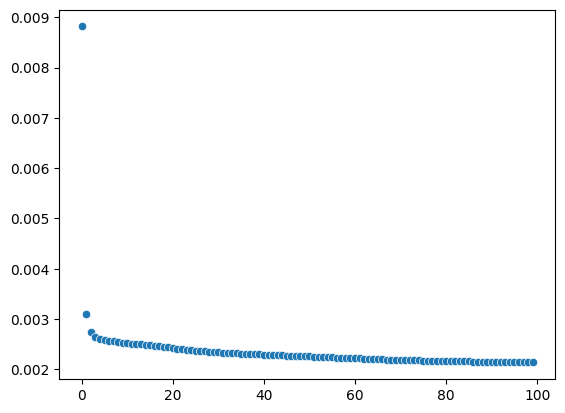

In [ ]:
n_in = 10
n_out = 2 * n_fold
epochs = 100
batch_size = 64
layers = 2
neurons = 64
# filenames
filenamenn   = f"harm_nn_{layers}_{neurons}_gelu.keras"
filenamehist = f"harm_hist_{layers}_{neurons}_gelu.pkl"
filepathnn   = os.path.join(dirname, filenamenn)
filepathhist = os.path.join(dirname, filenamehist)

# ---------------- build NN (always) ----------------
nn = build_harm_nn(
    n_in,
    n_out,
    layers=layers,
    width=neurons,
    act="gelu",
)

# ---------------- wrap with cached-geometry model ----------------
harm_form = HarmonicFormModelCachedPB(
    nn,
    ncoords=ncoords,
    n_fold=n_fold,
    levi=levi_civita_tensor(n_fold),
    clip_norm=1.0,
)

harm_form.compile(
    optimizer=tfk.optimizers.AdamW(
        learning_rate=2e-4,
        weight_decay=1e-4,
    ),
    metrics=[tfk.metrics.MeanAbsoluteError(name="mae")],
)

# ---------------- dataset ----------------
ds = make_dataset_cached_pb(
    pts,
    rhs,
    pbs_all=pbs,
    g_cy_pb_all=g_cy,
    g_inv_pb_all=g_inv,
    d_gcy_z_pb_all=d_g_cy_z_pb,
    d_ginv_z_pb_all=d_g_inv_z_pb,
    omega_pb_all=omega,
    d_omega_z_pb_all=d_omega_z_pb,
    batch_size=batch_size,
    shuffle=True,
)

# ---------------- train ONLY if needed ----------------
if not os.path.exists(filepathnn):
    print(f"[TRAIN] No existing model found at {filepathnn}")
    print("[TRAIN] Starting training...")

    history = harm_form.fit(ds, epochs=epochs)

    # save ONLY the NN (not the wrapper)
    nn.save(filepathnn)

    # save training history
    with open(filepathhist, "wb") as f:
        pickle.dump(history.history, f)

    print("[TRAIN] Training finished and model saved.")
    history = history.history

else:
    print(f"[LOAD] Found existing model at {filepathnn}")
    print("[LOAD] Skipping training.")

    # load NN only
    nn = tfk.models.load_model(filepathnn)

    # rebuild wrapper around loaded NN
    harm_form = HarmonicFormModelCachedPB(
        nn,
        ncoords=ncoords,
        n_fold=n_fold,
        levi=levi_civita_tensor(n_fold),
        clip_norm=1.0,
    )

    harm_form.compile(
        optimizer=tfk.optimizers.AdamW(
            learning_rate=2e-4,
            weight_decay=1e-4,
        ),
        metrics=[tfk.metrics.MeanAbsoluteError(name="mae")],
    )

    # optionally load history
    if os.path.exists(filepathhist):
        with open(filepathhist, "rb") as f:
            history = pickle.load(f)
    else:
        history = None
        
sns.scatterplot(x=range(len(history['mae'])), y=history['mae']);


# Solve the warp factor equation

Now we solve the EOM of the warp factor $A$,
$$\widetilde{\nabla}^2 \left( \text{e}^{-4A} \right) = -\frac{G_{ijk}\,\tilde{\bar G}^{ijk}}{12 \text{Im} \tau} - 2 \kappa_{10}^2 T_3 \tilde \rho_3^\text{loc}\,,$$
where
$$\tilde \rho^\text{loc}_3 = \sum_i N_i \frac{1}{\sqrt{\tilde g}} \delta^{6}(y-y_i)\,,$$
and
$$T_3=2\pi/l_S^4\,,\quad \kappa_{10}^2=l_S^8/(2\pi) \quad \Rightarrow\quad \kappa_{10}^2 T_3=l_S^4=1\,.$$
Moreover, we will choose the source term to be smeared, i.e., to give a constant contribution over all of the CY. Otherwise, since the sources are fully localized, we would never sample them.

The Laplacian $\widetilde{\nabla}^2$ simplifies on a Kahler manifold to
$$\widetilde{\nabla}^2=-2g^{\bar{i}j}\bar\partial_{\bar i}\partial_j$$
Remarkably, the derivatives of the metric and its determinant drop out, and $\widetilde{\nabla}^2 f$ only depends on derivatives w.r.t $f$.

In order to define the flux term, we need to use the (3,0) form $\Omega$ and the (2,1) form $\chi$. 

We define the flux term in two different ways: 
1) We will NOT use the harmonic (2,1) form trained above but calcuate $\chi\wedge\bar\chi$ as in the Keller Lukic https://arxiv.org/abs/0907.1387. See the notebook on the calculation for the WP metric for more details. Then $\Omega\wedge\bar\Omega$ is just obtained from the weights. This makes use of the fact that $\chi$ and $\Omega$ are (anti-) self-dual which is NOT true for $\chi$ as we are not using the harmonic (2,1) form. The advantage is that the contraction $G_{ijk} G^{ijk}$ can be calculated without using the learned boosted CY metric which should reduce the error. On the other hand the error is increased because we are not using the trained harmonic (2,1) form.
2) Here we use the trained harmonic (2,1) form and calculate $G_{ijk} G^{ijk}$ explicitly using the Hodge star and therefore also the learned boosted CY metric. This method has the opposite advantages/disadvantages of the method 1.

## Method 1

In [ ]:
tfpts = tf.cast(pts, dtype=tf.float32)
# --- calculate the derivatives of the \thetas if not already existent
filepath = os.path.join(dirname, "d_thetas_improved_phi2.npz")
d_thetas = calc_d_theta_par(
        target_file=filepath,
        pts=tfpts,
        DQDZB=DQDZB, DQDZF=DQDZF,
        DDQDZB=DDQDZB, DDQDZF=DDQDZF,
        qI=qI, ncoords=ncoords,
        comp_model=phimodel_2,
        pg=pg,
        batch_size=1000,
)

points = tf.cast(tf.complex(pts[:, :ncoords], pts[:, ncoords:]), dtype=tf.complex64)

# d_theta_z, d_theta_bz
d_theta_re_dz_re = d_thetas[..., 0, :5]
d_theta_im_dz_re = d_thetas[..., 1, :5]
d_theta_re_dz_im = d_thetas[..., 0, 5:]
d_theta_im_dz_im = d_thetas[..., 1, 5:]
d_theta_z = 0.5 * tf.complex(d_theta_re_dz_re + d_theta_im_dz_im,
                             d_theta_im_dz_re - d_theta_re_dz_im)
d_theta_bz = 0.5 * tf.complex(d_theta_re_dz_re - d_theta_im_dz_im,
                              d_theta_im_dz_re + d_theta_re_dz_im)

is_one = tf.equal(points, tf.complex(1.0, 0.0))
patch_idx = tf.argmax(tf.cast(is_one, tf.int32), axis=1, output_type=tf.int32)

# pullback
pbs = pullbacks(pg, points, j_elim=None)
bpbs = tf.cast(tf.math.conj(pbs), tf.complex64)

# delete the row in d_theta_bz corresponding to max_dQ_coord (vectorized)
max_dQ_coord = pg._find_max_dQ_coords(points)                 # typically numpy (N, nhyper)
max_dQ_coord = tf.convert_to_tensor(max_dQ_coord[:, 0], tf.int32)  # (N,)
index = max_dQ_coord - tf.cast(max_dQ_coord > patch_idx, tf.int32) # (N,) adjusted

N = tf.shape(d_theta_bz)[0]
rows = tf.tile(tf.range(ncoords - 1, dtype=tf.int32)[None, :], [N, 1])   # (N, ncoords-1)
keep = tf.not_equal(rows, index[:, None])
gather_rows = tf.reshape(tf.boolean_mask(rows, keep), [N, ncoords - 2])  # (N, ncoords-2)

dbthetas = tf.gather(d_theta_bz, gather_rows, batch_dims=1, axis=1)      # (N, ncoords-2, ncoords)
dbthetas = tf.cast(dbthetas, tf.complex64)

dbthetas_pb = tf.einsum("xij,xkj->xik", dbthetas, bpbs)                  # (N, ncoords-2, ncoords-2)
p21 = dbthetas_pb * tf.constant([[-1], [1], [-1]], dtype=dbthetas_pb.dtype)

# pattern tensor for result -- introduces minus signs at right positions
shape_mat = (ncoords - 2, ncoords - 2)
ii, jj = tf.meshgrid(tf.range(shape_mat[0]), tf.range(shape_mat[1]), indexing='ij')
pattern_tensor = tf.cast(tf.pow(-1, ii + jj + 1), tf.complex64)

res = tf.einsum("ij,xij,xji->x", pattern_tensor, p21, tf.math.conj(p21))

Put together the RHS of the warp factor equation: 
1) Define the flux vacuum and the corresponding $F_3$ and $H_3$ fluxes.
2) In order to match the tadpole (here $N_\text{flux}=8$ we need to match the integrals $\int \Omega\wedge\bar\Omega$ and $\int\chi\wedge\bar\chi$ obtained from the periods. So we rescale our numerical results for these integrals to match the period results.
(The proportionality constants for both integrals would be the same if we would obtained the exact value of the WP metric numerically.)
3) Define the RHS of the warp factor equation by first calculating the flux term. We rescale this term by kappa for better training performance. Then, in order to make the Poisson equation solvable (integral over RHS should be zero), we introduce a negative, constant flux density representing a would-be orintifold. 

In [ ]:
# calculate the labels, i.e., the RHS of the PDE
kappa = BASIS['KAPPA']

# input from mathematica notebook, example close to conifold
F3_harm = tf.constant([-1.0884381263210758 - 0.8162193370911293j, 0.2874464286903389 + 0.5534051931170548j], dtype = tf.complex64)
H3_harm = tf.constant ([0.25268110351686146- 0.27911615791604133j, -0.1598296913068312+0.06509510358182428j], dtype = tf.complex64)
tau = tf.constant(-0.33302682699814845+3.5981024815471585j, dtype = tf.complex64)
Imtau = tf.cast(tf.math.imag(tau), dtype = tf.complex64)
G3_harm = F3_harm - tau*H3_harm

omega = holomorphic_volume_form(pg, points)

# define proportionality constant to match period results and hence also the tadpole
vol_period = 16.9413  # period input
chi_barchi_period = 4.28303  # period input 
c_vol = vol_period / 5.
chi_barchi_num = tf.reduce_mean(res * tf.cast(wo[:,0],dtype=tf.complex64)) * kappa
c_chi = chi_barchi_period / chi_barchi_num 
print("c_vol =", c_vol)
print("c_chi =", c_chi)

warp_factor_rhs = -1./(2. * Imtau) * (res * kappa * G3_harm[0] * tf.math.conj(G3_harm[0]) * c_chi + kappa * G3_harm[1] * tf.math.conj(G3_harm[1]) * c_vol )
print("The RHS should be real. The min/avg/max imaginary parts are: {:.4e}, {:.4e}, {:.4e}".format(tf.reduce_min(tf.math.abs(tf.math.imag(warp_factor_rhs))), tf.reduce_mean(tf.math.abs(tf.math.imag(warp_factor_rhs))), tf.reduce_max(tf.math.abs(tf.math.imag(warp_factor_rhs)))))
warp_factor_rhs = tf.math.real(warp_factor_rhs)

# now we add a source term. We add it such that \int_X \rho_3 = N_flux = 9 in our case
N_flux = -tf.reduce_mean(warp_factor_rhs * wo[:,0])

warp_factor_rhs +=  N_flux / np.mean(wo[:, 0])
print("The Integral of the RHS w/o source terms should be N_flux = 8, and comes out as: {:.4f}".format(N_flux))
print("The Integral of the RHS w/  source terms should be 0, and comes out as:          {:.4e}".format(tf.reduce_mean(warp_factor_rhs * wo[:,0])))

In [ ]:
# define NN for the warp factor
layers = 2
neurons = 64
n_in = 10
n_out = 1
act = 'gelu'
epochs = 50
batch_size = 64

warp_nn = tf.keras.Sequential()
warp_nn.add(tfk.Input(shape=(n_in)))
for i in range(layers):
    warp_nn.add(tfk.layers.Dense(neurons, activation=act))
warp_nn.add(tfk.layers.Dense(n_out, use_bias=True))

model_name = f'warp_nn_phi2_{layers}_{neurons}_gelu_correct_constant_contr'
model_path = os.path.join(dirname, f'{model_name}.keras')
hist_path  = os.path.join(dirname, f'{model_name}_hist.pickle')

if not os.path.exists(model_path):
    warp_fac = WarpFactorModel(warp_nn, phimodel_2)
    warp_fac.compile(optimizer='adam', metrics=['mae'])

    warp_hist = warp_fac.fit(
        pts,
        tf.math.real(warp_factor_rhs),
        epochs=epochs,
        batch_size=batch_size
    )

    warp_fac.model.save(model_path)
    with open(hist_path, 'wb') as hnd:
        pickle.dump(warp_hist.history, hnd)

warp_nn = tfk.models.load_model(model_path)
warp_fac = WarpFactorModel(warp_nn, phimodel_2)

with open(hist_path, 'rb') as hnd:
    warp_hist = pickle.load(hnd)

sns.scatterplot(x=range(len(warp_hist['mae'])),y=warp_hist['mae'])

## Method 2

In [ ]:
# Calculate the learned correction to the harmonic (2,1) forms X
with tf.GradientTape() as tape:
    tape.watch(pts)
    delta_m = harm_form(pts)
d_delta_m = tape.batch_jacobian(delta_m, pts)

re_dz_re = d_delta_m[...,0:n_fold,:ncoords]
im_dz_re = d_delta_m[...,n_fold:,:ncoords]
re_dz_im = d_delta_m[...,0:n_fold,ncoords:]
im_dz_im = d_delta_m[...,n_fold:,ncoords:]
d_delta_m_bz = 1./2. * tf.complex(re_dz_re - im_dz_im, im_dz_re + re_dz_im)
pbs = pullbacks(pg, points, j_elim = None)
bpbs = tf.math.conj(pbs)
bpbs = tf.cast(bpbs, dtype = tf.complex64)
d_delta_m_bz_pb = tf.einsum('xij,xkj->xki',d_delta_m_bz,bpbs) #derivative is first index

X_harm = X + d_delta_m_bz_pb


epsilon3 = tf.cast(levi_civita_tensor(3), dtype=tf.complex64)
omega = holomorphic_volume_form(pg, points)
G3_harm_psi = kappa * G3_harm[0] * tf.einsum('xbi,x,jki->xjkb', X_harm, omega, epsilon3)/2.
G3_harm_omega = kappa * G3_harm[1] * tf.einsum('x,ijk->xijk', omega, epsilon3)

# we transpose the metric for the (2,1)-form part since the index structure is g_{i\bar j} and hence the inverse metric has index structure g^{\bar j k}
g_cy = phimodel_2(tf.cast(pts, dtype=tf.float32))
g_cy_inv_t = tf.einsum('xab->xba', tf.linalg.inv(g_cy))

c_vol = vol_period / 5.
omega3 = kappa* tf.einsum('x,ijk->xijk', omega, epsilon3)
c_vol = vol_period / (tf.reduce_mean(tf.einsum('xijk,xlmn,xil,xjm,xkn->x', omega3, tf.math.conj(omega3), g_cy_inv_t, g_cy_inv_t, g_cy_inv_t) * tf.cast(wo[:,0],dtype=tf.complex64)) / 6.)

In [ ]:
chi_num = kappa * tf.einsum('xbi,x,jki->xjkb', X_harm ,omega, epsilon3)/2.
ch_barchi_num =  1./6. * tf.reduce_mean(tf.cast(wo[:,0], dtype=tf.complex64) * tf.einsum('xijk,xlmn,xil,xjm,xnk->x', chi_num, tf.math.conj(chi_num), g_cy_inv_t, g_cy_inv_t, g_cy_inv_t))
c_chi = chi_barchi_period / ch_barchi_num 
warp_factor_rhs = -1./(12. * Imtau) * \
                        (c_vol * tf.einsum('xijk,xlmn,xil,xjm,xkn->x', G3_harm_omega, tf.math.conj(G3_harm_omega), g_cy_inv_t, g_cy_inv_t, g_cy_inv_t) + 
                         c_chi* tf.einsum('xijk,xlmn,xil,xjm,xnk->x', G3_harm_psi, tf.math.conj(G3_harm_psi), g_cy_inv_t, g_cy_inv_t, g_cy_inv_t))
print("The RHS should be real. The min/avg/max imaginary parts are: {:.4e}, {:.4e}, {:.4e}".format(tf.reduce_min(tf.math.abs(tf.math.imag(warp_factor_rhs))), tf.reduce_mean(tf.math.abs(tf.math.imag(warp_factor_rhs))), tf.reduce_max(tf.math.abs(tf.math.imag(warp_factor_rhs)))))
warp_factor_rhs = tf.math.real(warp_factor_rhs)

N_flux = -tf.reduce_mean(warp_factor_rhs * wo[:,0]) 
warp_factor_rhs +=  N_flux / tf.reduce_mean(wo[:, 0]) 

print(N_flux)
print("The Integral of the RHS w/  source terms should be 0, and comes out as:          {:.4e}".format(tf.reduce_mean(warp_factor_rhs * wo[:,0])))

In [ ]:
# train NN for warp factor using method 2

layers = 2
neurons = 64
act = 'gelu'

warp_nn = tf.keras.Sequential()
warp_nn.add(tfk.Input(shape=(n_in)))
for i in range(layers):
    warp_nn.add(tfk.layers.Dense(neurons, activation=act))
warp_nn.add(tfk.layers.Dense(n_out, use_bias=True))

model_name = f'warp_nn_FS_phi2_{layers}_{neurons}_using_metric_constant_contr'
model_path = os.path.join(dirname, f'{model_name}.keras')
hist_path  = os.path.join(dirname, f'{model_name}_hist.pickle')
print(model_path)
if not os.path.exists(model_path):
    warp_fac = WarpFactorModel(warp_nn, phimodel_2)
    warp_fac.compile(optimizer='adam', metrics=['mae'])

    warp_hist = warp_fac.fit(
        pts,
        tf.math.real(warp_factor_rhs),
        epochs=epochs,
        batch_size=batch_size
    )

    warp_fac.model.save(model_path)
    with open(hist_path, 'wb') as hnd:
        pickle.dump(warp_hist.history, hnd)

warp_nn = tfk.models.load_model(model_path)
warp_fac = WarpFactorModel(warp_nn, phimodel_2)

with open(hist_path, 'rb') as hnd:
    warp_hist = pickle.load(hnd)

sns.scatterplot(x=range(len(warp_hist['mae'])),y=warp_hist['mae'])

## Plot results for warp factor

In [ ]:
# for this dataset, no rescaling was performed 

def load_and_process(model_path, phimodel, pts, kappa):
    warp_nn = tfk.models.load_model(model_path)
    warp_fac = WarpFactorModel(warp_nn, phimodel)
    warp_facs = warp_fac(pts).numpy().flatten()             # model output (train normalization undone if needed)
    u_phys = warp_facs * (1.0 / float(kappa))               # multiply everything with 1/kappa (physical scale)
    u_shift = u_phys - np.min(u_phys)                       # Option A: shift by minimum (keeps positivity)
    return u_shift, u_phys

# collect all processed arrays
arrays = []
names = []

kappa =tf.math.real(tf.reduce_mean(BASIS['KAPPA']))

# first model (layers=2, neurons=64)
layers = 2; neurons = 64
model_name = f'warp_nn_phi2_{layers}_{neurons}_gelu_correct_constant_contr'
model_path = os.path.join(dirname, f'{model_name}.keras')
warp_facs1, u1_phys = load_and_process(model_path, phimodel_2, pts, kappa)
print("Min/Avg/Max: {:.4e} / {:.4e} / {:.4e}".format(np.min(warp_facs1), np.mean(warp_facs1), np.max(warp_facs1)))

arrays.append(warp_facs1); names.append("method 1, NN: L2 N64")

# second model (layers=2, neurons=64)
layers = 2; neurons = 64
model_name = f'warp_nn_FS_phi2_{layers}_{neurons}_using_metric_constant_contr'
model_path = os.path.join(dirname, f'{model_name}.keras')
warp_facs2, u2_phys = load_and_process(model_path, phimodel_2, pts, kappa)
print("Min/Avg/Max: {:.4e} / {:.4e} / {:.4e}".format(np.min(warp_facs2), np.mean(warp_facs2), np.max(warp_facs2)))

arrays.append(warp_facs2); names.append("method 2, NN: L2 N64")


# Plot: use common automatic bins computed from the combined data so histograms are comparable
#all_data = np.concatenate(arrays)
#bins = np.histogram_bin_edges(all_data, bins='auto')

# Plot only the range [0, 0.05]
xmin, xmax = 0.0, 0.05
bin_width = 0.001   # choose resolution
bins = np.arange(xmin, xmax + bin_width, bin_width)

plt.figure(figsize=(6, 4))

for arr, label in zip(arrays, names):
    plt.hist(
        arr,
        bins=bins,
        alpha=0.5,
        label=label,
        density=False
    )

plt.xlim(xmin, xmax)
plt.xlabel(r"$e^{-4A}_{\rm phys} - \min(e^{-4A}_{\rm phys})$")
plt.ylabel("count")
plt.title("Warp factor distributions (zoom: 0 – 0.05)")
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(7, 5))

for wf, label in zip(arrays, names):
    
    # --- optional normalization (recommended) ---
    w = wf / np.mean(wf)
    
    # sort
    w_sorted = np.sort(w)
    
    # CCDF
    ccdf = 1.0 - np.arange(1, len(w_sorted) + 1) / len(w_sorted)
    
    plt.plot(w_sorted, ccdf, label=label)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$e^{-4A}/\langle e^{-4A}\rangle$")
plt.ylabel(r"$P(e^{-4A} > x)$")
plt.title(f"CCDF of Warp Factor, Standard sampling dataset {n_try}" )
plt.legend()
plt.tight_layout()
fig_path = os.path.join(base_dir, f"CCDF_standard_set_{n_try}_before_boosting.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
